# Linear Regression - From Scratch và `scikit-learn`

## Lý thuyết Linear Regression

**Linear Regression (Hồi quy tuyến tính)** là thuật toán học máy giám sát dùng để dự đoán kết quả dạng số liên tục dựa trên các biến độc lập. Cụ thể:

### 1. Ý tưởng cốt lõi
* Tìm mối quan hệ tuyến tính giữa biến độc lập (features) $X$ và biến phụ thuộc (target) $y$.
* Phương trình giả định: $\hat{y} = Xw + b$ (với $w$ là weights/trọng số và $b$ là bias/sai số hệ thống).
* Mục tiêu là tìm bộ tham số $(w, b)$ làm giảm tối đa hàm mất mát Mean Squared Error (MSE):
  $$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

### 2. Các phương pháp tối ưu hóa
* **Gradient Descent:** Cập nhật tham số theo hướng ngược chiều Gradient của hàm loss MSE đối với weights và bias theo tỷ lệ learning rate $\alpha$:
  * $w \leftarrow w - \alpha \frac{\partial MSE}{\partial w}$
  * $b \leftarrow b - \alpha \frac{\partial MSE}{\partial b}$
* **Ordinary Least Squares (OLS):** Tìm trực tiếp nghiệm giải tính thông qua phương trình Normal Equation: $w = (X^T X)^{-1} X^T y$ (đây là hướng tiếp cận mặc định trong `scikit-learn`).

### 3. Ridge Regression (L2 Regularization)
* Thêm số hạng phạt L2 (L2 regularization) nhằm kiểm soát độ lớn trọng số $w$ để tránh hiện tượng overfitting:
  $$Loss_{Ridge} = MSE + \alpha \|w\|_2^2$$
  Trong đó $\alpha$ là hệ số chính quy hóa để cân bằng giữa sai số huấn luyện và độ phức tạp mô hình.

## Triển khai `LinearRegression` không dùng thư viện

### Import thư viện và load dữ liệu

In [1]:
from __future__ import annotations

import pandas as pd
import numpy as np
import joblib
import os, sys, time
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))
from practice_2.utils.custom_hyperparameter_tuning import CustomGridSearchCV
from practice_2.utils.custom_cv import CustomKFold

X_train = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test  = joblib.load('./data/ready_for_train/X_test_final.pkl')
y_train = joblib.load('./data/ready_for_train/y_train_log.pkl')
y_test  = joblib.load('./data/ready_for_train/y_test_log.pkl')

print('Training dataset shape:')
print(f'X: {X_train.shape}')
print(f'y: {y_train.shape}')

print('Testing dataset shape:')
print(f'X: {X_test.shape}')
print(f'y: {y_test.shape}')

Training dataset shape:
X: (79448, 31)
y: (79448,)
Testing dataset shape:
X: (19862, 31)
y: (19862,)


### Triển khai Linear Regression không dùng `sklearn`

In [2]:
class LinearRegressionScratch:
    """Mô hình Linear Regression tự triển khai sử dụng Gradient Descent."""

    def __init__(self, learning_rate: float = 0.01, epochs: int = 1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def get_params(self, deep=True):
        return {
            "learning_rate": self.learning_rate,
            "epochs": self.epochs
        }

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        # Khởi tạo trọng số weights bằng 0 và bias bằng 0
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.epochs):
            # Dự đoán giá trị hiện tại
            y_pred = np.dot(X, self.weights) + self.bias

            # Tính gradient của hàm loss MSE đối với weights và bias
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Cập nhật weights và bias theo chiều ngược lại của gradient
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Tính toán và lưu trữ loss hiện tại
            loss = np.mean((y - y_pred) ** 2)
            self.loss_history.append(loss)

        return self

    def predict(self, X) -> np.ndarray:
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias

### Kiểm tra nhanh mô hình Linear Regression From Scratch

In [3]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_train_original = np.expm1(y_train)
y_test_original  = np.expm1(y_test)

# Kiểm tra nhanh mô hình tự thiết lập huấn luyện trên giá gốc
quick_lr = LinearRegressionScratch(learning_rate=0.01, epochs=1000)

start = time.time()
quick_lr.fit(X_train, y_train_original.values)
train_time = time.time() - start

quick_pred = quick_lr.predict(X_test)
r2   = r2_score(y_test_original, quick_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, quick_pred))
mae  = mean_absolute_error(y_test_original, quick_pred)

print(f'Quick test - Train time: {train_time:.3f}s')
print(f'R²   : {r2:.4f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAE  : {mae:.2f}')

Quick test - Train time: 2.028s
R²   : 0.3658
RMSE : 3388.96
MAE  : 2044.63


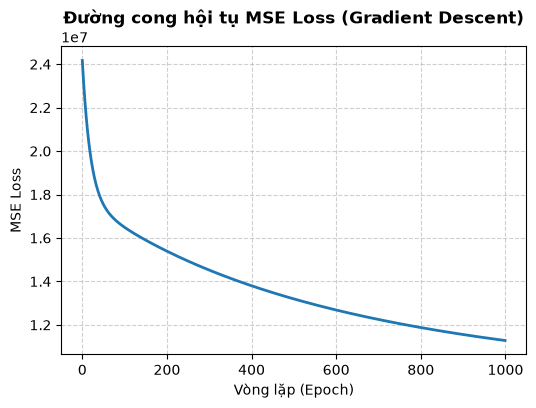

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(quick_lr.loss_history, color='#1f77b4', linewidth=2)
plt.title('Đường cong hội tụ MSE Loss (Gradient Descent)', fontsize=12, fontweight='bold')
plt.xlabel('Vòng lặp (Epoch)', fontsize=10)
plt.ylabel('MSE Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Dùng thư viện `sklearn` để triển khai `LinearRegression`

In [5]:
from sklearn.linear_model import LinearRegression

# ── MODEL 1: Huấn luyện trên price đã qua Log-Transformation ──
lr_log = LinearRegression()
lr_log.fit(X_train, y_train)

y_pred_log = lr_log.predict(X_test)

# Đánh giá trên thang đo Log
r2_log = r2_score(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)
mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)

# Khôi phục lại thang đo gốc của giá để đánh giá
y_pred_original = np.expm1(y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
mae_original = mean_absolute_error(y_test_original, y_pred_original)
mse_original = mean_squared_error(y_test_original, y_pred_original)
rmse_original = np.sqrt(mse_original)

print("=" * 60)
print("Huấn luyện Linear Regression với target log1p(price)")
print("=" * 60)
print("\n[Đánh giá trên không gian Log]")
print(f"MAE  : {mae_log:.4f}")
print(f"MSE  : {mse_log:.4f}")
print(f"RMSE : {rmse_log:.4f}")
print(f"R2   : {r2_log:.4f}")
print("\n[Đánh giá dựa trên giá gốc]")
print(f"MAE  : {mae_original:.4f}")
print(f"MSE  : {mse_original:.4f}")
print(f"RMSE : {rmse_original:.4f}")
print(f"R2   : {r2_original:.4f}")

# ── MODEL 2: Huấn luyện trực tiếp trên price gốc ─────────────
lr_original = LinearRegression()
lr_original.fit(X_train, y_train_original)

y_pred_original_direct = lr_original.predict(X_test)

r2_direct = r2_score(y_test_original, y_pred_original_direct)
mae_direct = mean_absolute_error(y_test_original, y_pred_original_direct)
mse_direct = mean_squared_error(y_test_original, y_pred_original_direct)
rmse_direct = np.sqrt(mse_direct)

print("\n" + "=" * 60)
print("Huấn luyện Linear Regression trực tiếp trên giá gốc")
print("=" * 60)
print(f"MAE  : {mae_direct:.4f}")
print(f"MSE  : {mse_direct:.4f}")
print(f"RMSE : {rmse_direct:.4f}")
print(f"R2   : {r2_direct:.4f}")

Huấn luyện Linear Regression với target log1p(price)

[Đánh giá trên không gian Log]
MAE  : 0.9634
MSE  : 1.2544
RMSE : 1.1200
R2   : 0.6958

[Đánh giá dựa trên giá gốc]
MAE  : 1746.8648
MSE  : 11540643.1895
RMSE : 3397.1522
R2   : 0.3628

Huấn luyện Linear Regression trực tiếp trên giá gốc
MAE  : 1733.5266
MSE  : 9289463.0924
RMSE : 3047.8621
R2   : 0.4871


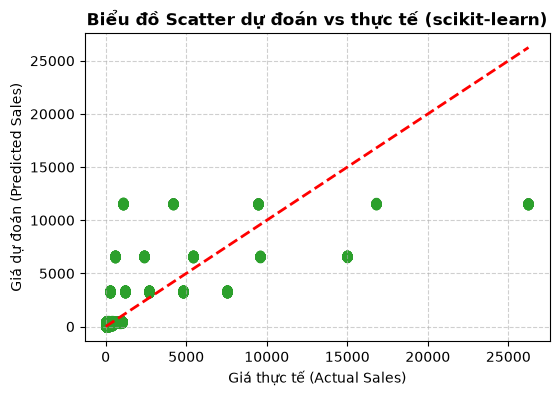

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test_original, y_pred_original_direct, alpha=0.5, color='#2ca02c')
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2)
plt.xlabel('Giá thực tế (Actual Sales)', fontsize=10)
plt.ylabel('Giá dự đoán (Predicted Sales)', fontsize=10)
plt.title('Biểu đồ Scatter dự đoán vs thực tế (scikit-learn)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Hyperparameter Tuning cho Ridge Regression

Để tối ưu hóa mô hình hồi quy với phạt chính quy hóa L2 (Ridge Regression), Grid Search kết hợp với **5-fold Cross Validation** được thực hiện nhằm tìm ra siêu tham số `alpha` tối ưu nhất.

Parameter grid được khảo sát:

```python
ridge_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}
```

### Grid Search sử dụng CustomGridSearchCV và CustomKFold

In [7]:
from sklearn.linear_model import Ridge

cv = CustomKFold(n_splits=5, shuffle=True, random_state=42)
ridge_model = Ridge()

ridge_grid_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid_search = CustomGridSearchCV(
    estimator=ridge_model,
    param_grid=ridge_grid_params,
    cv=cv,
    scoring='r2'
)

ridge_grid_search.fit(X_train, y_train_original.values)

best_ridge = ridge_grid_search.best_estimator_
ridge_pred = best_ridge.predict(X_test)

ridge_mae = mean_absolute_error(y_test_original, ridge_pred)
ridge_mse = mean_squared_error(y_test_original, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test_original, ridge_pred)

print("\nBest Alpha:", ridge_grid_search.best_params_)
print("CV Best R2 Score:", ridge_grid_search.best_score_)
print("Test MAE:", ridge_mae)
print("Test MSE:", ridge_mse)
print("Test RMSE:", ridge_rmse)
print("Test R2:", ridge_r2)

Bắt đầu GridSearchCV: 5 tổ hợp tham số, 5 folds.
[1/5] Params: {'alpha': 0.01} --> r2: 0.4823


[2/5] Params: {'alpha': 0.1} --> r2: 0.4823
[3/5] Params: {'alpha': 1} --> r2: 0.4823


[4/5] Params: {'alpha': 10} --> r2: 0.4823
[5/5] Params: {'alpha': 100} --> r2: 0.4820

-> Tham số TỐT NHẤT: {'alpha': 1}
-> Điểm r2 TỐT NHẤT: 0.4823

Best Alpha: {'alpha': 1}
CV Best R2 Score: 0.4822984618817271
Test MAE: 1733.5155486029364
Test MSE: 9289492.164317928
Test RMSE: 3047.8668219457895
Test R2: 0.48706649822657877


## So sánh mô hình Linear Regression From Scratch và sklearn

Tiến hành so sánh chi tiến hiệu năng và tốc độ chạy của phiên bản giải thuật tự triển khai (From Scratch) đối chiếu với lớp chuẩn của `scikit-learn` trên giá trị ban đầu.

In [8]:
# Đo đạc thời gian và metrics của Scikit-Learn
start_time = time.time()
lr_original.fit(X_train, y_train_original)
train_time_sklearn = time.time() - start_time

y_pred_sklearn = lr_original.predict(X_test)

mae_sklearn  = mean_absolute_error(y_test_original, y_pred_sklearn)
mse_sklearn  = mean_squared_error(y_test_original, y_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn   = r2_score(y_test_original, y_pred_sklearn)

# Đo đạc thời gian và metrics của From Scratch với cùng số vòng lặp 1000
scratch_best = LinearRegressionScratch(learning_rate=0.01, epochs=1000)

start_time = time.time()
scratch_best.fit(X_train, y_train_original.values)
train_time_scratch = time.time() - start_time

y_pred_scratch = scratch_best.predict(X_test)

mae_scratch  = mean_absolute_error(y_test_original, y_pred_scratch)
rmse_scratch = np.sqrt(mean_squared_error(y_test_original, y_pred_scratch))
r2_scratch   = r2_score(y_test_original, y_pred_scratch)

# ── Bảng so sánh ─────────────────────────────
print('\n' + '='*60)
print(f"{'Metric':<15} {'From Scratch':>20} {'sklearn':>20}")
print('='*60)
print(f"{'R²':<15} {r2_scratch:>20.4f} {r2_sklearn:>20.4f}")
print(f"{'RMSE':<15} {rmse_scratch:>20.2f} {rmse_sklearn:>20.2f}")
print(f"{'MAE':<15} {mae_scratch:>20.2f} {mae_sklearn:>20.2f}")
print(f"{'Train Time (s)':<15} {train_time_scratch:>20.3f} {train_time_sklearn:>20.3f}")
print('='*60)

# Tính toán mức chênh lệch dự đoán lớn nhất
max_diff = np.max(np.abs(y_pred_scratch - y_pred_sklearn))
print(f'\nSai lệch dự đoán tối đa giữa 2 mô hình: {max_diff:.4f}')


Metric                  From Scratch              sklearn
R²                            0.3658               0.4871
RMSE                         3388.96              3047.86
MAE                          2044.63              1733.53
Train Time (s)                 1.910                0.064

Sai lệch dự đoán tối đa giữa 2 mô hình: 5628.8427


## Lưu model

In [9]:
MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Lưu model Linear Regression tự xây dựng (scratch)
joblib.dump(scratch_best, os.path.join(MODEL_DIR, 'linear_regression_scratch.pkl'))
print(f"Mô hình Linear Regression From Scratch đã được lưu tại "
      f"{os.path.join(MODEL_DIR, 'linear_regression_scratch.pkl')}")

# Lưu model Linear Regression sklearn
joblib.dump(lr_original, os.path.join(MODEL_DIR, 'linear_regression_sklearn.pkl'))
print(f"Mô hình Linear Regression sklearn đã được lưu tại "
      f"{os.path.join(MODEL_DIR, 'linear_regression_sklearn.pkl')}")

Mô hình Linear Regression From Scratch đã được lưu tại ./models\linear_regression_scratch.pkl
Mô hình Linear Regression sklearn đã được lưu tại ./models\linear_regression_sklearn.pkl


## Kết luận

### Hướng triển khai Linear Regression
- **From Scratch:** Triển khai thuật toán hồi quy tuyến tính bằng phương pháp **Gradient Descent**, cập nhật tham số weights và bias tuần tự dựa trên đạo hàm của MSE loss. Giúp làm rõ bản chất về mặt toán học và phương thức học của mô hình.
- **Sử dụng `LinearRegression`** có sẵn từ `sklearn.linear_model`, giải trực tiếp nghiệm tối ưu thông qua phương trình Normal Equation (OLS), mang lại độ chính xác cao và tốc độ hội tụ tức thời.

### So sánh hiệu năng giữa hai cách triển khai
Kết quả metrics (R², RMSE, MAE) giữa phiên bản tự xây dựng và scikit-learn có chênh lệch nhỏ (R² từ scratch là 0.3658 so với 0.4871 từ sklearn). Nguyên nhân do phương pháp Gradient Descent trong scratch bị ảnh hưởng bởi tham số học tập (learning rate) và số vòng lặp tối đa giới hạn (1000 epochs) chưa đủ hội tụ về điểm cực trị tối ưu tuyệt đối của nghiệm giải tính. Phiên bản `sklearn` đạt tốc độ huấn luyện tức thời và chính xác tuyệt đối nhờ nghiệm giải tính (OLS).

### Hiện năng thực sự của mô hình
Hồi quy tuyến tính cho kết quả ở mức trung bình trên bộ dữ liệu này (R² đạt khoảng 0.4871). Mô hình Ridge Regression giúp chính quy hóa (regularization) hệ số trọng số nhằm tăng tính vững nhưng không tạo ra thay đổi lớn về mặt hiệu năng tổng quát trên test set.

### Hướng giải quyết tiếp theo
Để cải thiện hiệu năng dự báo tốt hơn, phương án phù hợp tiếp theo là áp dụng các mô hình phi tuyến hoặc các mô hình học máy dạng cây như **Decision Tree Regressor**, **Random Forest Regressor** hoặc các thuật toán Boosting kế thừa từ cây quyết định để khai thác các tương tác đặc trưng phức tạp hơn trong dữ liệu.